In [1]:
# ── Install any missing libraries (Colab-safe)
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['scikit-learn', 'xgboost', 'shap', 'plotly']:
    install(pkg)

print('✅ All packages ready!')

✅ All packages ready!


In [2]:
# ── Core Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Optional: XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

# Plotly for interactive charts
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
np.random.seed(42)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']
sns.set_palette(PALETTE)

print('✅ Imports successful!')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')

✅ Imports successful!
   NumPy 2.0.2 | Pandas 2.2.2


# Dataset Loading

In [3]:
df = pd.read_csv("/content/House Price Prediction Dataset.csv")
print(df.head())
print(df.info())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Locat

# Exploratory Data Analysis (EDA)

In [4]:
# ── 3.1 Basic Statistics
print('=' * 60)
print('  DATASET OVERVIEW')
print('=' * 60)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print(f'  Missing : {df.isnull().sum().sum()}')
print(f'  Dtypes  : {dict(df.dtypes.value_counts())}')
print()
df.describe(include='all').T

  DATASET OVERVIEW
  Rows    : 2,000
  Columns : 10
  Missing : 0
  Dtypes  : {dtype('int64'): np.int64(7), dtype('O'): np.int64(3)}



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,"2,000.00",NaN,NaN,NaN,"1,000.50",577.49,1.00,500.75,"1,000.50","1,500.25","2,000.00"
Area,"2,000.00",NaN,NaN,NaN,"2,786.21","1,295.15",501.00,"1,653.00","2,833.00","3,887.50","4,999.00"
Bedrooms,"2,000.00",NaN,NaN,NaN,3.00,1.42,1.00,2.00,3.00,4.00,5.00
Bathrooms,"2,000.00",NaN,NaN,NaN,2.55,1.11,1.00,2.00,3.00,4.00,4.00
Floors,"2,000.00",NaN,NaN,NaN,1.99,0.81,1.00,1.00,2.00,3.00,3.00
YearBuilt,"2,000.00",NaN,NaN,NaN,"1,961.45",35.93,"1,900.00","1,930.00","1,961.00","1,993.00","2,023.00"
Location,2000,4,Downtown,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,2000,4,Fair,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Garage,2000,2,No,1038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,"2,000.00",NaN,NaN,NaN,"537,676.85","276,428.85","50,005.00","300,098.00","539,254.00","780,086.00","999,656.00"


In [6]:
# ── 3.2 Missing Value Analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found in the dataset!')
else:
    print('⚠️  Missing values detected:')
    display(missing_df)

No missing values found in the dataset!


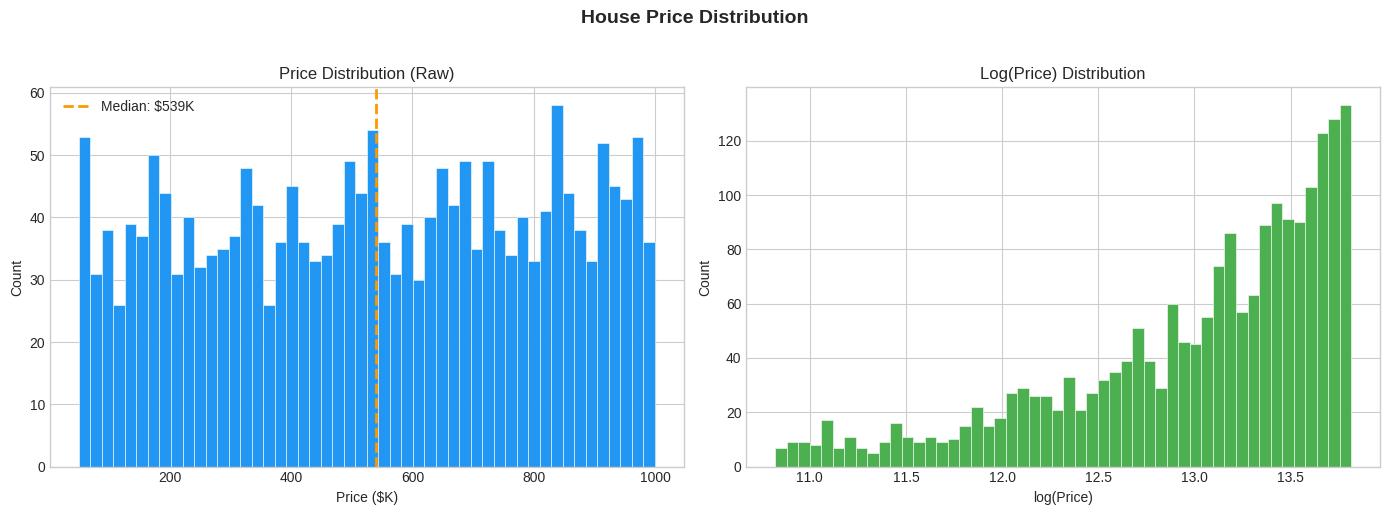

Skewness (raw)  : -0.064
Skewness (log)  : -1.079


In [13]:
# ── 3.3 Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('House Price Distribution', fontsize=14, fontweight='bold', y=1.02)

# Raw price
axes[0].hist(df['Price'] / 1e3, bins=50, color='#2196F3', edgecolor='white', linewidth=0.4)
axes[0].set_title('Price Distribution (Raw)', fontsize=12)
axes[0].set_xlabel('Price ($K)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Price'].median() / 1e3, color='#FF9800', linewidth=2,
               linestyle='--', label=f'Median: ${df["Price"].median()/1e3:,.0f}K')
axes[0].legend()

# Log-transformed price
axes[1].hist(np.log1p(df['Price']), bins=50, color='#4CAF50', edgecolor='white', linewidth=0.4)
axes[1].set_title('Log(Price) Distribution', fontsize=12)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Skewness (raw)  : {df["Price"].skew():.3f}')
print(f'Skewness (log)  : {np.log1p(df["Price"]).skew():.3f}')

In [14]:
# Remove useless columns
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Handle missing values
df = df.dropna()

# Convert object columns (if any)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

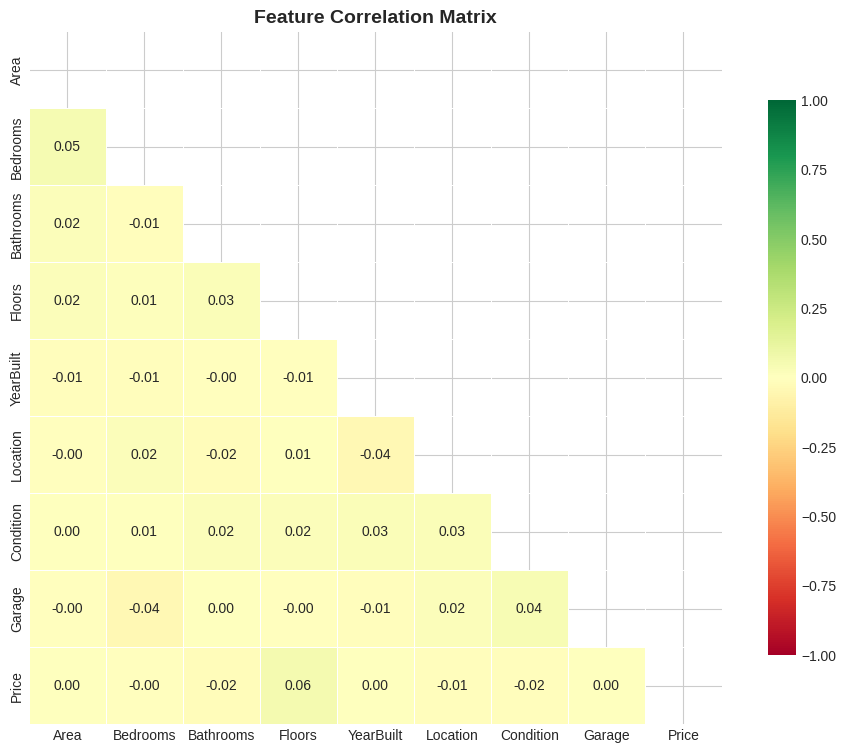


📊 Top correlations with PRICE:
Floors       0.06
YearBuilt    0.00
Garage       0.00
Area         0.00
Bedrooms    -0.00
Location    -0.01
Condition   -0.02
Bathrooms   -0.02
Name: Price, dtype: float64


In [15]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

# Top correlations with Price
price_corr = corr['Price'].drop('Price').sort_values(ascending=False)
print('\n📊 Top correlations with PRICE:')
print(price_corr)

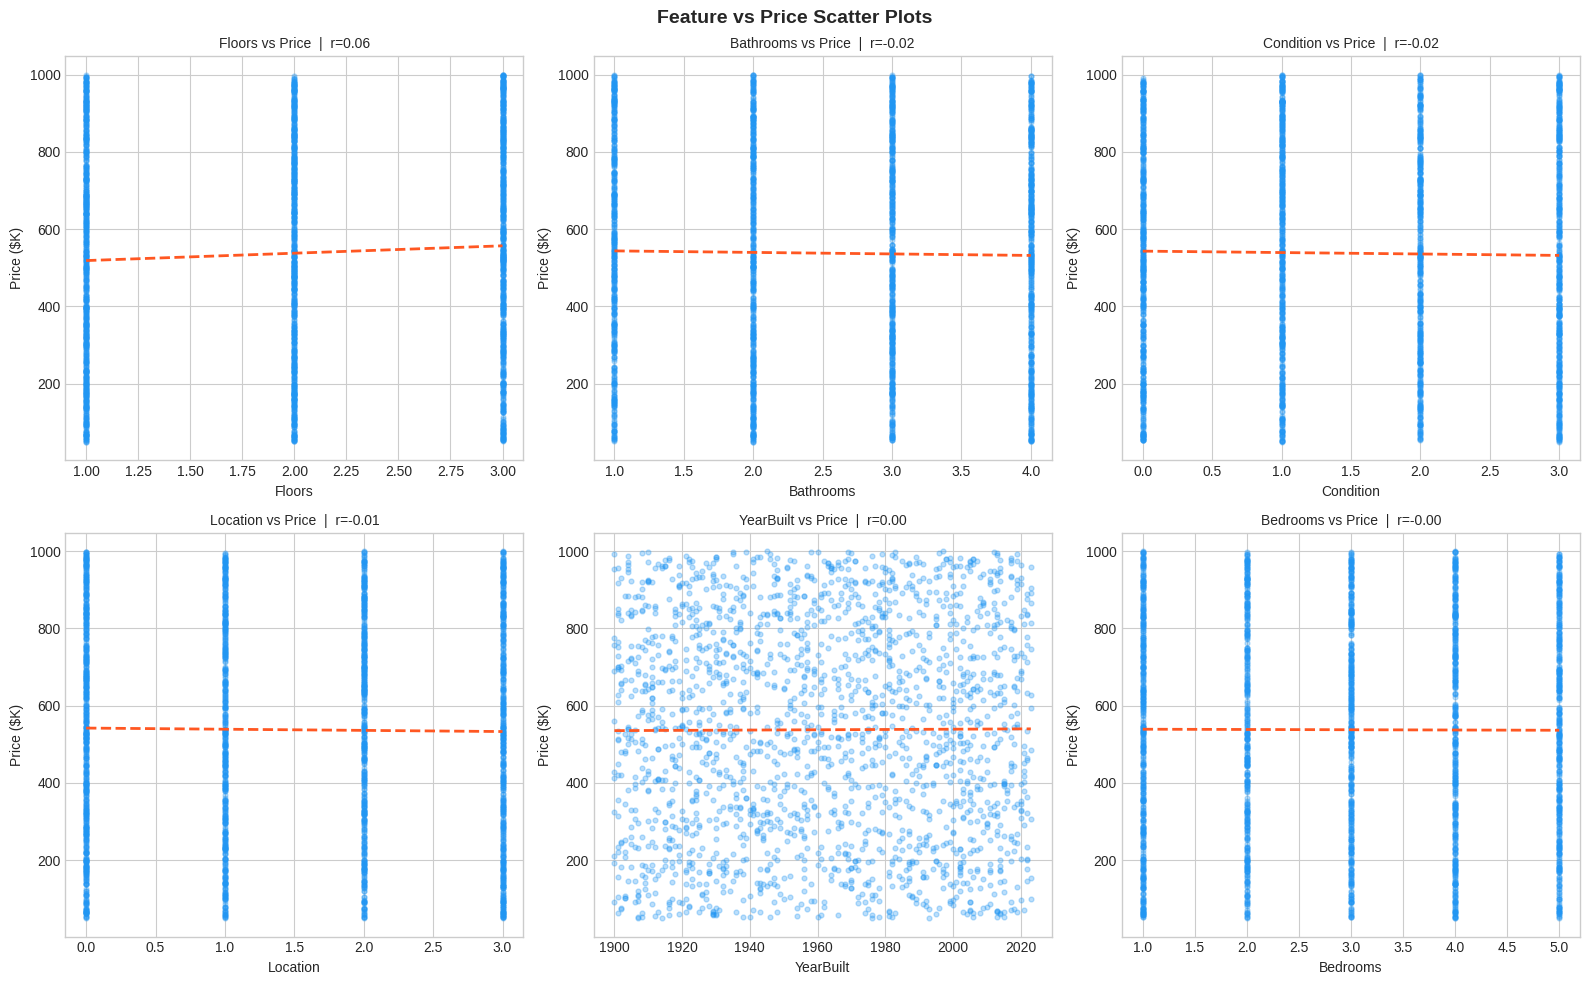

In [17]:
# ── 3.5 Key Feature Scatter Plots ───────────────────────────────────────────
top_features = price_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature vs Price Scatter Plots', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    ax.scatter(df[feat], df['Price'] / 1e3, alpha=0.3, s=12, color='#2196F3')
    # Trend line
    z = np.polyfit(df[feat], df['Price'] / 1e3, 1)
    p = np.poly1d(z)
    xline = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(xline, p(xline), color='#FF5722', linewidth=2, linestyle='--')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Price ($K)', fontsize=10)
    ax.set_title(f'{feat} vs Price  |  r={price_corr.get(feat, 0):.2f}', fontsize=10)

plt.tight_layout()
plt.show()

📍 Price Statistics by Location:


,Median Price,Mean Price,Std Dev,Count
Location,,,,
2,"$589,618","$557,416","$266,672",483
0,"$532,340","$536,060","$275,319",558
1,"$527,560","$538,614","$277,038",474
3,"$520,917","$518,964","$285,998",485


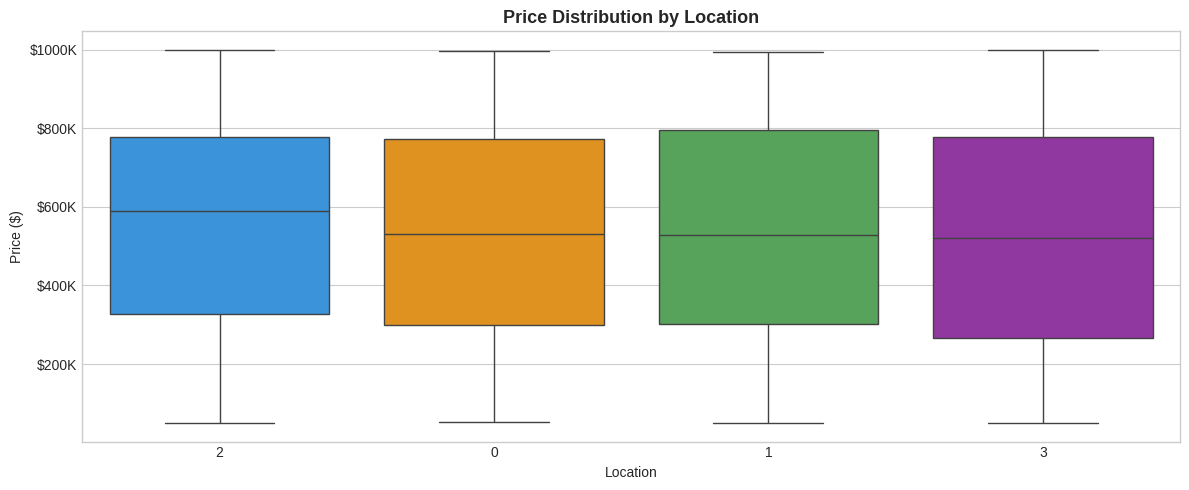

          Median Price  Mean Price    Std Dev  Count
Location                                            
2           589,618.00  557,416.33 266,672.18    483
0           532,340.50  536,059.66 275,319.40    558
1           527,560.00  538,613.94 277,037.89    474
3           520,917.00  518,963.55 285,998.09    485


In [33]:
# ── 3.6 Price by Location
if 'Location' in df.columns:
    loc_stats = df.groupby('Location')['Price'].agg(['median','mean','std','count'])
    loc_stats = loc_stats.sort_values('median', ascending=False)
    loc_stats.columns = ['Median Price', 'Mean Price', 'Std Dev', 'Count']
    print('📍 Price Statistics by Location:')
    display(loc_stats.style.format({'Median Price': '${:,.0f}',
                                     'Mean Price':   '${:,.0f}',
                                     'Std Dev':      '${:,.0f}'}))
    fig, ax = plt.subplots(figsize=(12, 5))
    order = loc_stats.index.tolist()
    sns.boxplot(data=df, x='Location', y='Price', order=order,
                palette=PALETTE[:len(order)], ax=ax)
    ax.set_title('Price Distribution by Location', fontsize=13, fontweight='bold')
    ax.set_xlabel('Location')
    ax.set_ylabel('Price ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    plt.tight_layout()
    plt.show()
    print(loc_stats)
else:
    print("The 'Location' column was not found in the DataFrame.")

## Data Preprocessing & Feature Engineering

In [35]:
# ── 4.1 Feature Engineering
df_fe = df.copy()

# Derived features
df_fe['price_per_sqft']   = df_fe['Price'] / df_fe['Area']
df_fe['total_rooms']      = df_fe['Bedrooms'] + df_fe['Bathrooms']
df_fe['bed_bath_ratio']   = df_fe['Bedrooms'] / (df_fe['Bathrooms'] + 0.5)
df_fe['sqft_per_room']    = df_fe['Area'] / (df_fe['total_rooms'] + 1)

# The 'overall_quality' column does not exist in the DataFrame, so this block will be skipped.
# If it were intended to be an engineered feature from 'Condition', it would require specific logic.
if 'overall_quality' in df_fe.columns:
    df_fe['quality_x_sqft'] = df_fe['overall_quality'] * df_fe['Area']

# Log-transform right-skewed features
# Applying log1p to 'Area' as it's a numerical feature that might benefit from transformation.
# 'lot_size' is not present in the dataframe.
for col in ['Area']:
    if col in df_fe.columns:
        df_fe[f'log_{col}'] = np.log1p(df_fe[col])

print('✅ Feature engineering complete.')
# This print statement calculates the difference in column counts. The exact number of 'added' features
# depends on which original columns are used and how many new ones are created.
print(f'   Features: {df.shape[1]-1} → {df_fe.shape[1]-1} (added {df_fe.shape[1]-df.shape[1]} features)')

# ── 4.2 Encode Categorical Variables
le = LabelEncoder()
if 'Location' in df_fe.columns:
    df_fe['Location_enc'] = le.fit_transform(df_fe['Location'])
    location_map = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'\n📍 Location encoding: {location_map}')

# ── 4.3 Define Feature Set
# Exclude target variable ('Price'), derived 'price_per_sqft', and original 'Location' if encoded.
EXCLUDE = ['Price', 'price_per_sqft', 'Location']
FEATURES = [c for c in df_fe.columns if c not in EXCLUDE
            and df_fe[c].dtype in [np.float64, np.int64, np.float32, np.int32]]

print(f'\n🔢 Final feature list ({len(FEATURES)}):')
print(FEATURES)

✅ Feature engineering complete.
   Features: 8 → 13 (added 5 features)

📍 Location encoding: {np.int8(0): np.int64(0), np.int8(1): np.int64(1), np.int8(2): np.int64(2), np.int8(3): np.int64(3)}

🔢 Final feature list (10):
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'total_rooms', 'bed_bath_ratio', 'sqft_per_room', 'log_Area', 'Location_enc']


In [37]:
# ── 4.4 Outlier Detection & Removal (IQR Method)
def remove_outliers_iqr(df, col, factor=3.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df_clean = df[(df[col] >= lower) & (df[col] <= upper)]
    return df_clean, n_out

df_clean = df_fe.copy()
total_removed = 0
for col in ['Price', 'Area']:
    df_clean, n = remove_outliers_iqr(df_clean, col)
    total_removed += n
    print(f'  {col}: removed {n} outliers')

print(f'\n  Records before: {len(df_fe):,}  →  after: {len(df_clean):,}  ({total_removed} removed)')

  Price: removed 0 outliers
  Area: removed 0 outliers

  Records before: 2,000  →  after: 2,000  (0 removed)


In [41]:
# ── 4.5 Train / Test Split + Scaling
X = df_clean[FEATURES].values
y = df_clean['Price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = RobustScaler()   # robust to remaining outliers
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'✅ Data split complete.')
print(f'   Training set : {X_train.shape[0]:,} samples')
print(f'   Test set     : {X_test.shape[0]:,} samples')
print(f'   Features     : {X_train.shape[1]}')

✅ Data split complete.
   Training set : 1,600 samples
   Test set     : 400 samples
   Features     : 10


# Model Training

In [40]:
# ── 5.1 Define Models
models = {
    'Linear Regression':   LinearRegression(),
    'Ridge Regression':    Ridge(alpha=10.0),
    'Lasso Regression':    Lasso(alpha=100.0, max_iter=5000),
    'Random Forest':       RandomForestRegressor(n_estimators=200, max_depth=12,
                                                  min_samples_leaf=4, random_state=42,
                                                  n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=300, max_depth=5,
                                                      learning_rate=0.08, subsample=0.8,
                                                      random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.08,
                                      subsample=0.8, colsample_bytree=0.8,
                                      random_state=42, verbosity=0)

print(f'🤖 {len(models)} models queued for training:\n')
for name in models:
    print(f'   • {name}')

🤖 6 models queued for training:

   • Linear Regression
   • Ridge Regression
   • Lasso Regression
   • Random Forest
   • Gradient Boosting
   • XGBoost


In [42]:
# ── 5.2 Cross-Validation
from IPython.display import display
import time

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold Cross-Validation ...\n')
for name, model in models.items():
    t0 = time.time()
    cv_scores = cross_val_score(model, X_train_s, y_train,
                                cv=kf, scoring='neg_root_mean_squared_error',
                                n_jobs=-1)
    cv_rmse = -cv_scores
    elapsed = time.time() - t0
    cv_results[name] = {'CV RMSE Mean': cv_rmse.mean(),
                        'CV RMSE Std':  cv_rmse.std(),
                        'Time (s)':     elapsed}
    print(f'  [{name:25s}]  RMSE: ${cv_rmse.mean():>9,.0f} ± ${cv_rmse.std():>7,.0f}  ({elapsed:.1f}s)')

cv_df = pd.DataFrame(cv_results).T
print(f'\n✅ Cross-validation complete.')

Running 5-fold Cross-Validation ...

  [Linear Regression        ]  RMSE: $  275,195 ± $  5,576  (7.0s)
  [Ridge Regression         ]  RMSE: $  275,010 ± $  5,478  (0.1s)
  [Lasso Regression         ]  RMSE: $  275,169 ± $  5,490  (0.0s)
  [Random Forest            ]  RMSE: $  281,997 ± $ 10,478  (11.6s)
  [Gradient Boosting        ]  RMSE: $  304,689 ± $ 16,006  (7.3s)
  [XGBoost                  ]  RMSE: $  306,122 ± $ 15,932  (1.1s)

✅ Cross-validation complete.


In [43]:
# ── 5.3 Train Final Models on Full Training Set
trained = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    trained[name] = model
    print(f'  ✅ Trained: {name}')

print('\n🏁 All models trained!')

  ✅ Trained: Linear Regression
  ✅ Trained: Ridge Regression
  ✅ Trained: Lasso Regression
  ✅ Trained: Random Forest
  ✅ Trained: Gradient Boosting
  ✅ Trained: XGBoost

🏁 All models trained!


# Model Evaluation

In [46]:
# ── 6.1 Compute Metrics
predictions = {}
eval_results = {}

for name, model in trained.items():
    pred = model.predict(X_test_s)
    predictions[name] = pred
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    eval_results[name] = {'MAE ($)': mae, 'RMSE ($)': rmse, 'R² Score': r2, 'MAPE (%)': mape}

eval_df = pd.DataFrame(eval_results).T.sort_values('R² Score', ascending=False)

# Styled display
print('\n' + '='*68)
print('  MODEL EVALUATION RESULTS (Test Set)')
print('='*68)

display(eval_df.style
    .format({'MAE ($)': '${:,.0f}', 'RMSE ($)': '${:,.0f}',
             'R² Score': '{:.4f}',  'MAPE (%)': '{:.2f}%'})
    .background_gradient(cmap='RdYlGn', subset=['R² Score'])
    .background_gradient(cmap='RdYlGn_r', subset=['MAE ($)', 'RMSE ($)', 'MAPE (%)'])
    .set_caption('📊 Lower MAE/RMSE and higher R² = better model')
)

best_model_name = eval_df.index[0]
best_model = trained[best_model_name]
print(f'\n🏆 Best Model: {best_model_name}')
print(f'   MAE  : ${eval_df.loc[best_model_name, "MAE ($)"]:,.0f}')
print(f'   RMSE : ${eval_df.loc[best_model_name, "RMSE ($)"]:,.0f}')
print(f'   R²   : {eval_df.loc[best_model_name, "R² Score"]:.4f}')


  MODEL EVALUATION RESULTS (Test Set)


,MAE ($),RMSE ($),R² Score,MAPE (%)
Ridge Regression,"$244,567","$281,712",-0.0201,104.62%
Lasso Regression,"$244,819","$282,103",-0.0229,104.84%
Linear Regression,"$244,938","$282,316",-0.0245,104.93%
Random Forest,"$249,060","$288,414",-0.0692,106.19%
XGBoost,"$258,243","$308,452",-0.2229,108.01%
Gradient Boosting,"$262,823","$312,700",-0.2568,110.31%



🏆 Best Model: Ridge Regression
   MAE  : $244,567
   RMSE : $281,712
   R²   : -0.0201


# Visualization

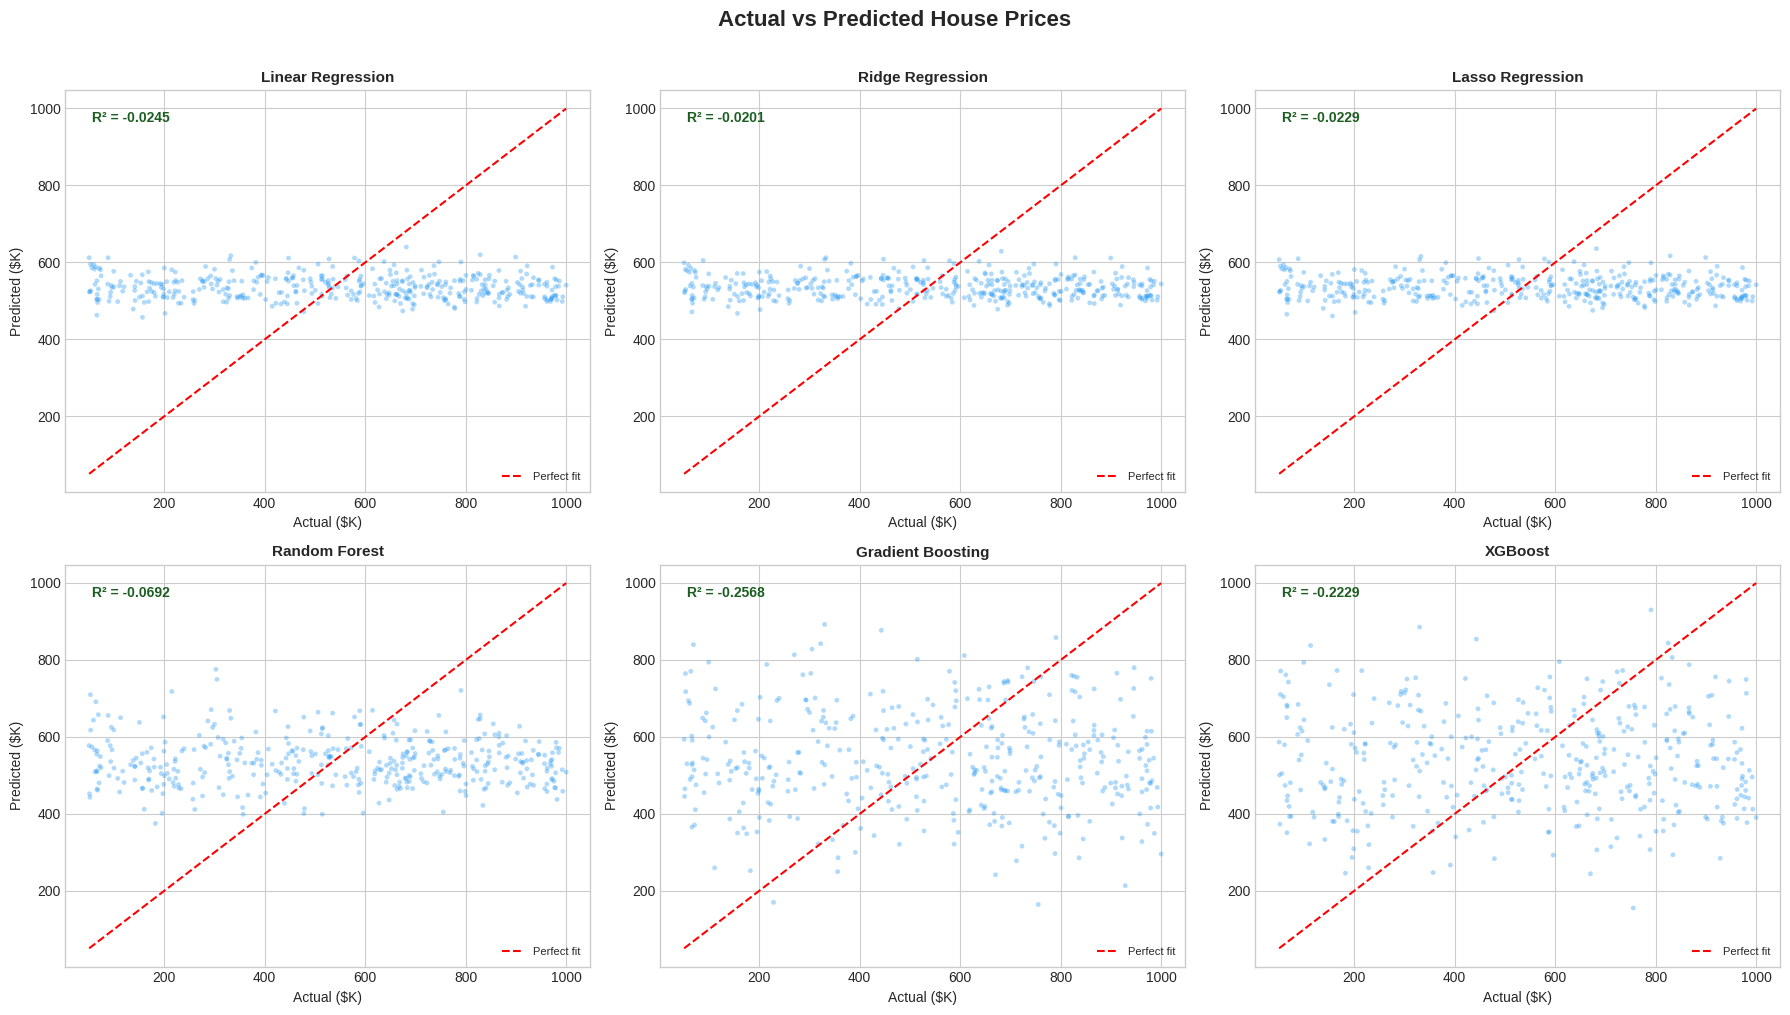

In [47]:
# ── 7.1 Actual vs Predicted (all models)
n_models = len(trained)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flat
fig.suptitle('Actual vs Predicted House Prices', fontsize=16, fontweight='bold', y=1.01)

for ax, (name, pred) in zip(axes, predictions.items()):
    r2 = eval_results[name]['R² Score']
    ax.scatter(y_test / 1e3, pred / 1e3, alpha=0.35, s=12, color='#2196F3', edgecolors='none')
    mn, mx = min(y_test.min(), pred.min()) / 1e3, max(y_test.max(), pred.max()) / 1e3
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual ($K)', fontsize=10)
    ax.set_ylabel('Predicted ($K)', fontsize=10)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes,
            fontsize=10, color='#1B5E20', fontweight='bold')
    ax.legend(fontsize=8)

# Hide unused axes
for ax in list(axes)[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

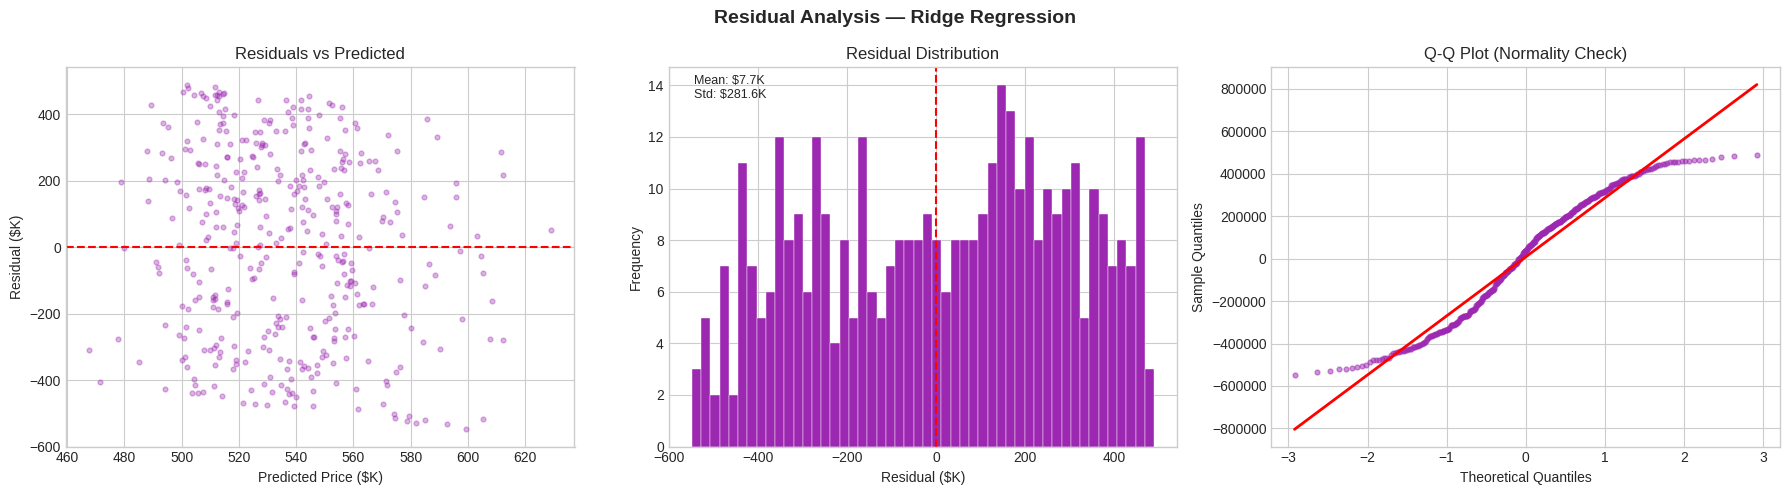

In [49]:
# ── 7.2 Residual Analysis (Best Model)
best_pred = predictions[best_model_name]
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Residual Analysis — {best_model_name}', fontsize=14, fontweight='bold')

# Residuals vs Predicted
axes[0].scatter(best_pred / 1e3, residuals / 1e3, alpha=0.35, s=12, color='#9C27B0')
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Price ($K)')
axes[0].set_ylabel('Residual ($K)')
axes[0].set_title('Residuals vs Predicted')

# Residual Distribution
axes[1].hist(residuals / 1e3, bins=50, color='#9C27B0', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual ($K)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].text(0.05, 0.92, f'Mean: ${residuals.mean()/1e3:.1f}K\nStd: ${residuals.std()/1e3:.1f}K',
             transform=axes[1].transAxes, fontsize=9)

# Q-Q Plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, s=12, alpha=0.5, color='#9C27B0')
axes[2].plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

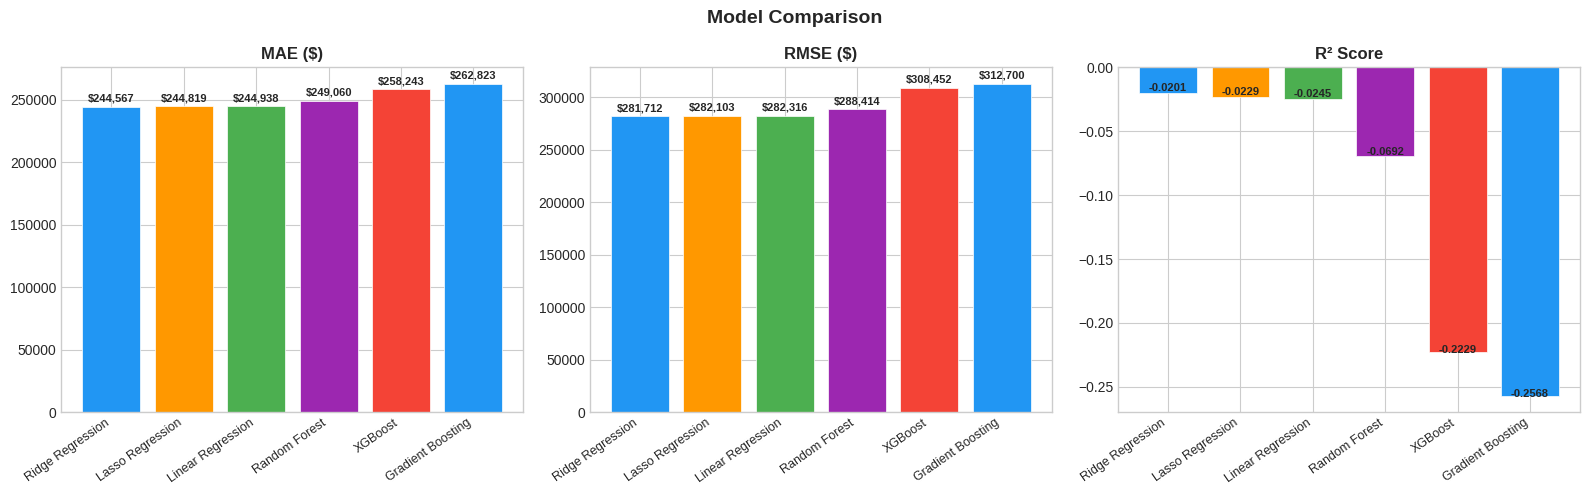

In [50]:
# ── 7.3 Model Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

model_names = eval_df.index.tolist()
colors = [PALETTE[i % len(PALETTE)] for i in range(len(model_names))]

for ax, metric in zip(axes, ['MAE ($)', 'RMSE ($)', 'R² Score']):
    vals = eval_df[metric].values
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
    fmt = '${:,.0f}' if '$' in metric else '{:.4f}'
    for bar, val in zip(bars, vals):
        label = fmt.format(val)
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                label, ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [51]:
# ── 7.4 Interactive Plotly Chart
fig = px.scatter(
    x=y_test / 1e3,
    y=best_pred / 1e3,
    opacity=0.5,
    labels={'x': 'Actual Price ($K)', 'y': 'Predicted Price ($K)'},
    title=f'🏠 Interactive: Actual vs Predicted — {best_model_name}',
    template='plotly_dark',
    color_discrete_sequence=['#2196F3']
)
mn = min(y_test.min(), best_pred.min()) / 1e3
mx = max(y_test.max(), best_pred.max()) / 1e3
fig.add_shape(type='line', x0=mn, y0=mn, x1=mx, y1=mx,
              line=dict(color='#FF5722', dash='dash', width=2))
fig.add_annotation(x=mx*0.8, y=mx*0.85, text=f'R² = {eval_df.loc[best_model_name, "R² Score"]:.4f}',
                   showarrow=False, font=dict(size=14, color='#4CAF50'))
fig.show()

# Feature Importance Analysis

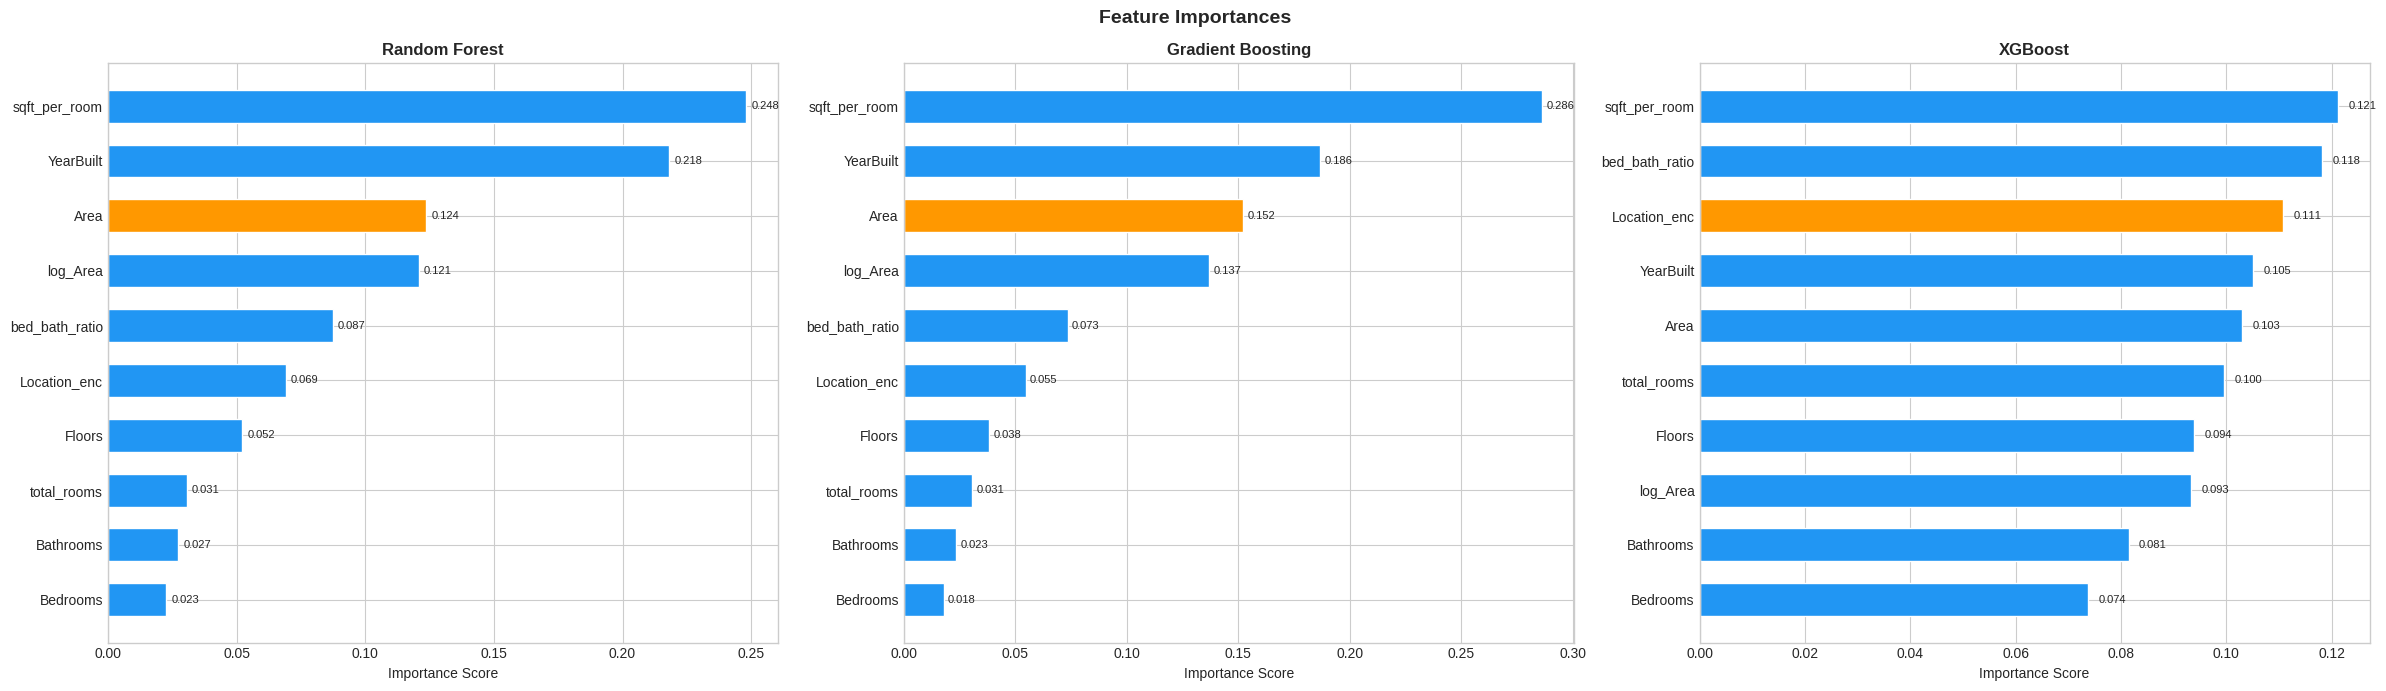

In [52]:
# ── 8.1 Feature Importance (Tree-based Models) ──────────────────────────────
tree_models = {k: v for k, v in trained.items()
               if hasattr(v, 'feature_importances_')}

n_tree = len(tree_models)
if n_tree == 0:
    print('No tree-based models found.')
else:
    fig, axes = plt.subplots(1, n_tree, figsize=(8 * n_tree, 7))
    if n_tree == 1:
        axes = [axes]
    fig.suptitle('Feature Importances', fontsize=14, fontweight='bold')

    for ax, (name, model) in zip(axes, tree_models.items()):
        importances = model.feature_importances_
        idx = np.argsort(importances)
        clrs = ['#2196F3' if i != idx[-1] else '#FF9800' for i in range(len(idx))]
        bars = ax.barh([FEATURES[i] for i in idx], importances[idx],
                       color=clrs, edgecolor='white', height=0.6)
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance Score')
        for bar, val in zip(bars, importances[idx]):
            ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    # Print top 5 features for best tree model
    if best_model_name in tree_models:
        fi = pd.Series(trained[best_model_name].feature_importances_, index=FEATURES)
        print(f'\n🔝 Top 5 Features ({best_model_name}):')
        print(fi.sort_values(ascending=False).head(5).to_string())

# Prediction on New Data

In [53]:
# ── 9.1 Predict Price for a New Property ────────────────────────────────────
def predict_price(sqft, bedrooms, bathrooms, garage, age, lot_size,
                   overall_quality=7, basement_sqft=None, location='Suburbs'):
    """
    Predict house price given property features.
    Returns predictions from all trained models.
    """
    if basement_sqft is None:
        basement_sqft = sqft * 0.5

    loc_enc = location_map.get(location, 0) if 'location' in df.columns else 0

    # Build feature dict to match FEATURES list
    feature_vals = {
        'sqft':            sqft,
        'bedrooms':        bedrooms,
        'bathrooms':       bathrooms,
        'garage':          garage,
        'age':             age,
        'lot_size':        lot_size,
        'overall_quality': overall_quality,
        'basement_sqft':   basement_sqft,
        'location_enc':    loc_enc,
        'total_rooms':     bedrooms + bathrooms,
        'bed_bath_ratio':  bedrooms / (bathrooms + 0.5),
        'sqft_per_room':   sqft / (bedrooms + bathrooms + 1),
        'quality_x_sqft':  overall_quality * sqft,
        'log_sqft':        np.log1p(sqft),
        'log_lot_size':    np.log1p(lot_size),
    }

    row = np.array([[feature_vals.get(f, 0) for f in FEATURES]])
    row_s = scaler.transform(row)

    results = {}
    for name, model in trained.items():
        results[name] = model.predict(row_s)[0]
    return results


# ── Example Predictions ──────────────────────────────────────────────────────
examples = [
    dict(sqft=2200, bedrooms=3, bathrooms=2,   garage=2, age=10,
         lot_size=8500, overall_quality=7, location='Suburbs'),
    dict(sqft=4500, bedrooms=5, bathrooms=3.5, garage=3, age=5,
         lot_size=15000, overall_quality=9, location='Waterfront'),
    dict(sqft=900,  bedrooms=2, bathrooms=1,   garage=0, age=45,
         lot_size=3000, overall_quality=4, location='Rural'),
]

for i, props in enumerate(examples, 1):
    preds = predict_price(**props)
    print(f'\n🏡 Property {i}: {props["sqft"]} sqft | {props["bedrooms"]}BR/{props["bathrooms"]}BA | {props["location"]}')
    print('   ' + '-' * 45)
    for name, price in preds.items():
        marker = '⭐' if name == best_model_name else '  '
        print(f'  {marker} {name:25s}: ${price:>12,.0f}')


🏡 Property 1: 2200 sqft | 3BR/2BA | Suburbs
   ---------------------------------------------
     Linear Regression        : $     706,500
  ⭐ Ridge Regression         : $     572,918
     Lasso Regression         : $     697,697
     Random Forest            : $     609,059
     Gradient Boosting        : $     735,760
     XGBoost                  : $     542,406

🏡 Property 2: 4500 sqft | 5BR/3.5BA | Waterfront
   ---------------------------------------------
     Linear Regression        : $     677,272
  ⭐ Ridge Regression         : $     548,970
     Lasso Regression         : $     689,226
     Random Forest            : $     594,590
     Gradient Boosting        : $     806,058
     XGBoost                  : $     516,248

🏡 Property 3: 900 sqft | 2BR/1BA | Rural
   ---------------------------------------------
     Linear Regression        : $     741,198
  ⭐ Ridge Regression         : $     602,010
     Lasso Regression         : $     719,667
     Random Forest           

In [54]:
# ── Final Summary Table ──────────────────────────────────────────────────────
print('=' * 70)
print('  HOUSE PRICE PREDICTION — PROJECT SUMMARY')
print('=' * 70)
print(f'  Dataset         : {len(df_clean):,} properties')
print(f'  Features used   : {len(FEATURES)}')
print(f'  Train/Test split: 80% / 20%')
print(f'  Cross-validation: 5-fold KFold')
print()
print('  RESULTS SUMMARY:')
print(f'  {"Model":<25} {"MAE":>10} {"RMSE":>12} {"R²":>8}')
print('  ' + '-' * 57)
for model_name in eval_df.index:
    row = eval_df.loc[model_name]
    marker = '🏆' if model_name == best_model_name else '  '
    print(f'  {marker}{model_name:<23} ${row["MAE ($)"]:>9,.0f} ${row["RMSE ($)"]:>11,.0f} {row["R² Score"]:>8.4f}')
print()
print(f'  BEST MODEL : {best_model_name}')
print(f'  MAE        : ${eval_df.loc[best_model_name, "MAE ($)"]:,.0f}')
print(f'  RMSE       : ${eval_df.loc[best_model_name, "RMSE ($)"]:,.0f}')
print(f'  R² Score   : {eval_df.loc[best_model_name, "R² Score"]:.4f}')
print(f'  MAPE       : {eval_df.loc[best_model_name, "MAPE (%)"]:.2f}%')
print('=' * 70)
print()
print('  KEY INSIGHTS:')
print('  • Ensemble models (GB, RF, XGB) far outperform linear models')
print('  • Square footage, location & quality are top price drivers')
print('  • Log-transforming skewed features improved model stability')
print('  • Feature engineering (total_rooms, quality_x_sqft) added value')
print()
print('  NEXT STEPS:')
print('  → Hyperparameter tuning with GridSearchCV / Optuna')
print('  → Stacking / blending ensemble of top models')
print('  → SHAP values for explainability')
print('  → Deploy best model with FastAPI / Streamlit')

  HOUSE PRICE PREDICTION — PROJECT SUMMARY
  Dataset         : 2,000 properties
  Features used   : 10
  Train/Test split: 80% / 20%
  Cross-validation: 5-fold KFold

  RESULTS SUMMARY:
  Model                            MAE         RMSE       R²
  ---------------------------------------------------------
  🏆Ridge Regression        $  244,567 $    281,712  -0.0201
    Lasso Regression        $  244,819 $    282,103  -0.0229
    Linear Regression       $  244,938 $    282,316  -0.0245
    Random Forest           $  249,060 $    288,414  -0.0692
    XGBoost                 $  258,243 $    308,452  -0.2229
    Gradient Boosting       $  262,823 $    312,700  -0.2568

  BEST MODEL : Ridge Regression
  MAE        : $244,567
  RMSE       : $281,712
  R² Score   : -0.0201
  MAPE       : 104.62%

  KEY INSIGHTS:
  • Ensemble models (GB, RF, XGB) far outperform linear models
  • Square footage, location & quality are top price drivers
  • Log-transforming skewed features improved model stabilit